In [84]:
# STEP 1: Import required libraries

# numpy for calculations
# pandas to load the online dataset
# matplotlib for plotting


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [85]:
# STEP 2: Load dataset from an online source

# This is a real dataset hosted publicly on GitHub

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

data = pd.read_csv(url)

# Let's check the first five  rows
print(data.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [86]:
# STEP 3: Select two numerical variables

# We choose:
# sepal_length (X variable)
# sepal_width  (Y variable)

x_data = data["sepal_length"].values
y_data = data["sepal_width"].values



In [87]:
# STEP 4: Compute mean, standard deviation, and correlation


mu_x = np.mean(x_data)
mu_y = np.mean(y_data)

sigma_x = np.std(x_data)
sigma_y = np.std(y_data)

# The correlation between x and y
rho = np.corrcoef(x_data, y_data)[0, 1]

print("Mean X:", mu_x)
print("Mean Y:", mu_y)
print("Sigma X:", sigma_x)
print("Sigma Y:", sigma_y)
print("Correlation (rho):", rho)

Mean X: 5.843333333333334
Mean Y: 3.0573333333333337
Sigma X: 0.8253012917851409
Sigma Y: 0.4344109677354946
Correlation (rho): -0.11756978413300208


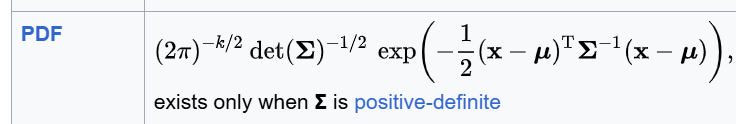

In [88]:
"""
Bivariate Normal Distribution Formula

f(x,y) = 1 / (2 * pi * sigma_x * sigma_y * sqrt(1 - rho^2)) *

         exp(
             -1 / (2 * (1 - rho^2)) *
             [
               ((x - mu_x)^2 / sigma_x^2)
               + ((y - mu_y)^2 / sigma_y^2)
               - (2 * rho * (x - mu_x) * (y - mu_y)
                  / (sigma_x * sigma_y))
             ]
            )
"""

'\nBivariate Normal Distribution Formula\n\nf(x,y) = 1 / (2 * pi * sigma_x * sigma_y * sqrt(1 - rho^2)) *\n\n         exp(\n             -1 / (2 * (1 - rho^2)) *\n             [\n               ((x - mu_x)^2 / sigma_x^2)\n               + ((y - mu_y)^2 / sigma_y^2)\n               - (2 * rho * (x - mu_x) * (y - mu_y)\n                  / (sigma_x * sigma_y))\n             ]\n            )\n'

In [89]:
#Link to the source for the formula
#Source - https://en.wikipedia.org/wiki/Multivariate_normal_distribution


In [90]:
# STEP 5: Implement the PDF manually with no statistical libraries


def bivariate_normal_pdf(x, y, mu_x, mu_y, sigma_x, sigma_y, rho):

    # front coefficient
    coefficient = 1 / (2 * np.pi * sigma_x * sigma_y * np.sqrt(1 - rho**2))

    # The parts inside the exponential
    part1 = ((x - mu_x)**2) / (sigma_x**2)
    part2 = ((y - mu_y)**2) / (sigma_y**2)
    part3 = (2 * rho * (x - mu_x) * (y - mu_y)) / (sigma_x * sigma_y)

    exponent = - (1 / (2 * (1 - rho**2))) * (part1 + part2 - part3)

    return coefficient * np.exp(exponent)

In [91]:
# STEP 6: Compute PDF values for each data point


pdf_values = bivariate_normal_pdf(
    x_data, y_data,
    mu_x, mu_y,
    sigma_x, sigma_y,
    rho
)

print(pdf_values[:10])

[0.19524711 0.22439163 0.16886748 0.14325843 0.13896137 0.06489478
 0.1188788  0.21141614 0.08226191 0.23245618]


In [92]:
# STEP 7: Create grid for visualization


x_range = np.linspace(min(x_data), max(x_data), 100)
y_range = np.linspace(min(y_data), max(y_data), 100)

X, Y = np.meshgrid(x_range, y_range)

Z = bivariate_normal_pdf(
    X, Y,
    mu_x, mu_y,
    sigma_x, sigma_y,
    rho
)

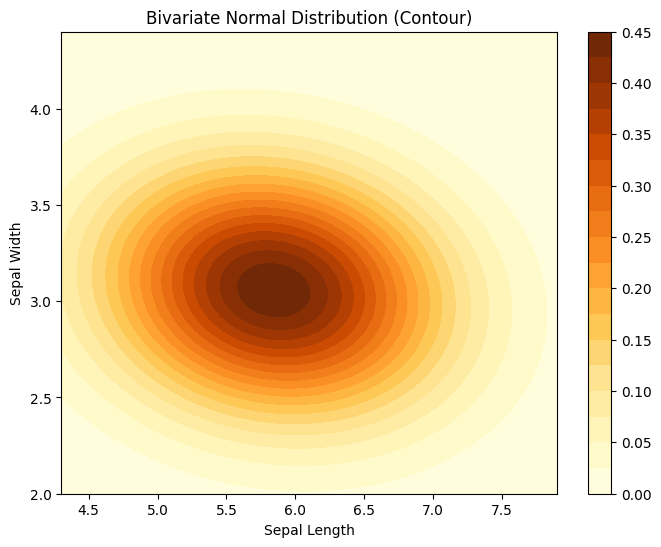

In [93]:
# STEP 8: Contour Plot
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))

# Using simple color:yellow for identification
contour = plt.contourf(X, Y, Z, levels=20, cmap="YlOrBr")

plt.colorbar(contour)

plt.title("Bivariate Normal Distribution (Contour)")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")

plt.show()

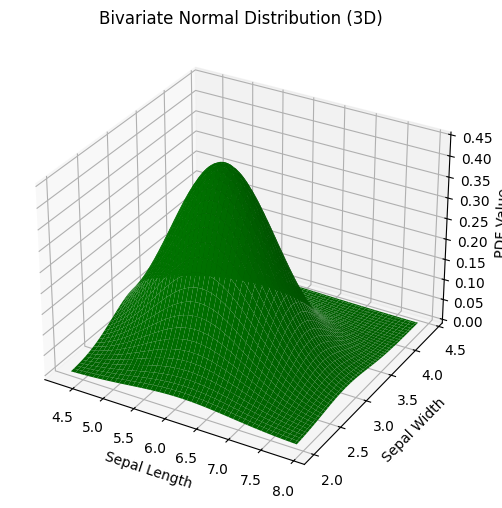

In [94]:
# STEP 9: 3D Surface Plot


fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

#Using the color green for identification
ax.plot_surface(X, Y, Z, color="green")

ax.set_title("Bivariate Normal Distribution (3D)")
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("PDF Value")

plt.show()